In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import IPython.display as ipd
import matplotlib.colors as colors
import parameters
import time_scheme
import xarray as xr
import grid

# Test de la classe Grid

In [3]:
params = parameters.Params()
params.Nx = 128
params.Ny = 256
params.geometry = 'zonal_channel'
params.dealias_params.apply_dealias = True
Grd = grid.Grid(params)
print(Grd)


Grid : 

Geometry = zonal_channel

- Size (128, 256) 

- Step : dx = 0.04908738521234052, dy = 7.588988516937789e-05

- Minimal step : 7.588988516937789e-05

- Intervals : x = (0.0, 6.283185307179586), y = (-1.0, 1.0) 

- DealiasParams : DealiasParams(apply_dealias=True, dealias_order='after_product', dealias_Fourier_coeff=0.6666666666666666, dealias_exp_alpha=100.0, dealias_exp_p=8.0)



On travaille sur la fonction
$$
f(x, y) = \cos^2 x\cosh{y}
$$
Avec $x \in [0, 2\pi]$, $y \in [-1, 1]$. Ses dérivées sont : 
$$
\begin{aligned}
\frac{\partial f}{\partial x} &= -\sin{2x}\cosh{y}\\
\frac{\partial^2 f}{\partial x^2} &= -2\cos{2x}\cosh{y}\\
\frac{\partial f}{\partial y} &= \cos^2 x\sinh{y}\\
\frac{\partial^2 f}{\partial y^2} &= \cos^2 x \cosh{y}\\
\Delta_{\mathrm{h}} f &= (-2\cos{2x}+\cos^2 x)\cosh{y}
\end{aligned}
$$
L'intégrale sur tout le domaine vaut : 
$$
\int_0^{2\pi}\int_{-1}^1 f(x, y) \mathrm{d}x\mathrm{d}y = 2\pi \sinh{1}
$$

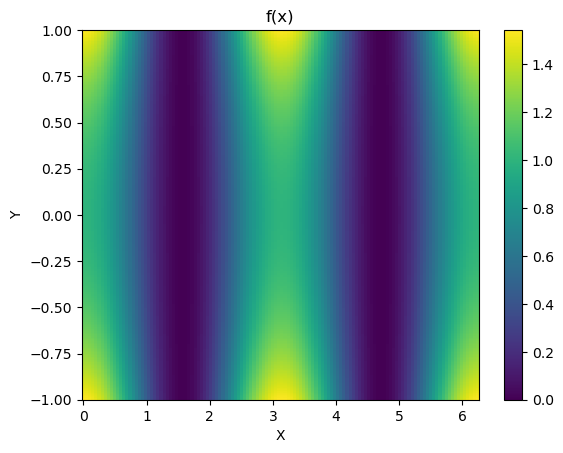

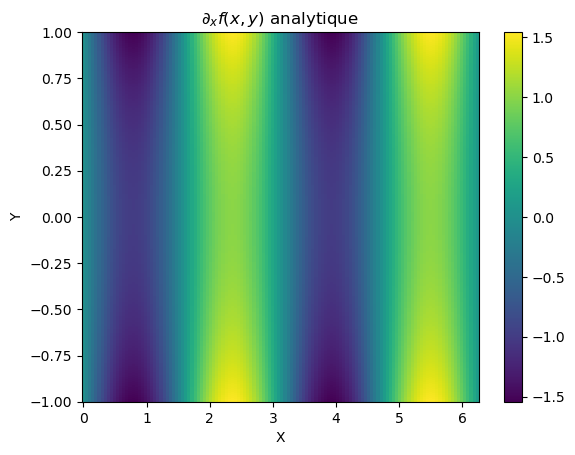

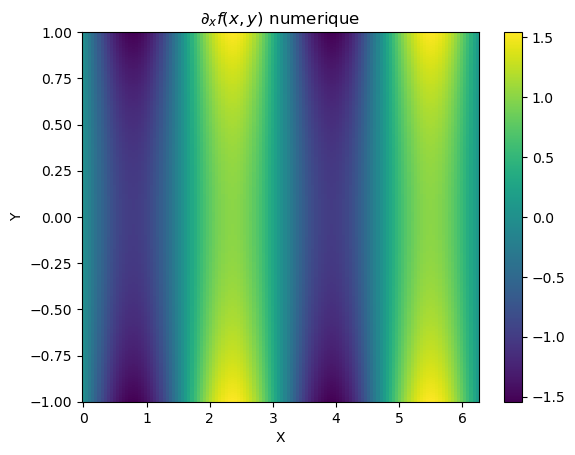

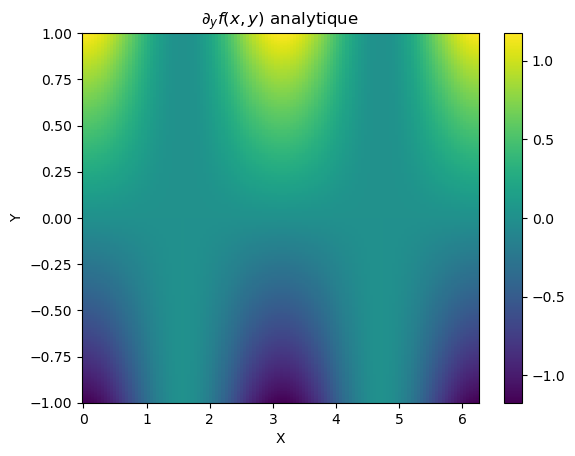

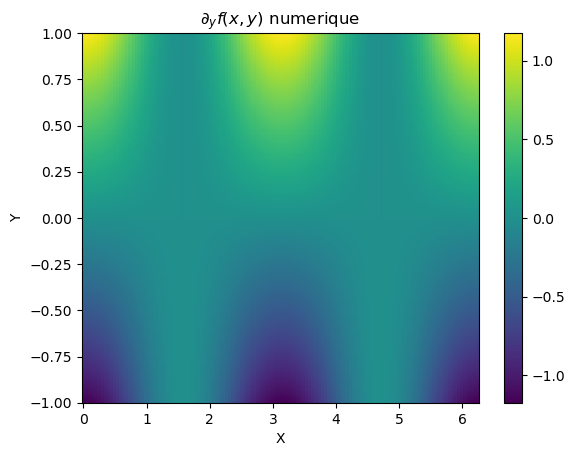

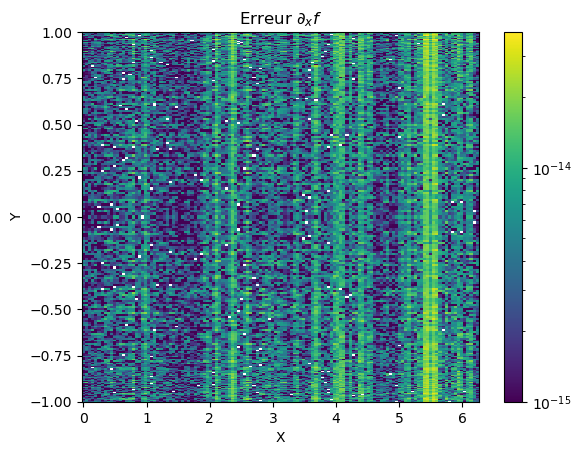

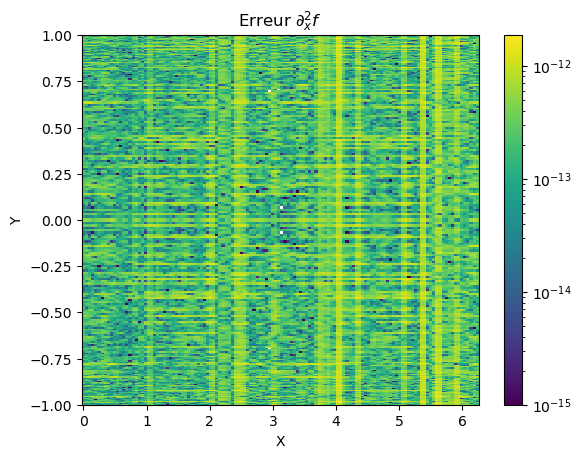

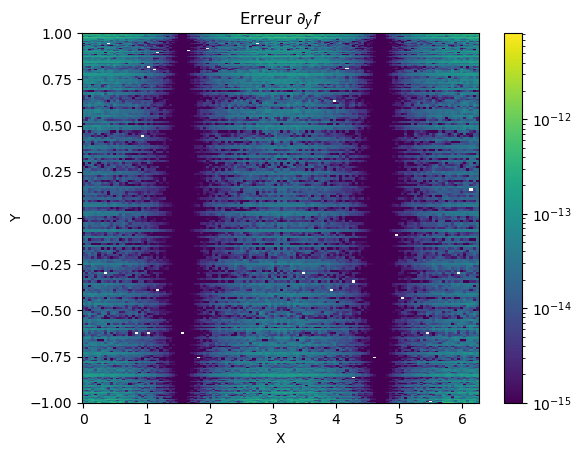

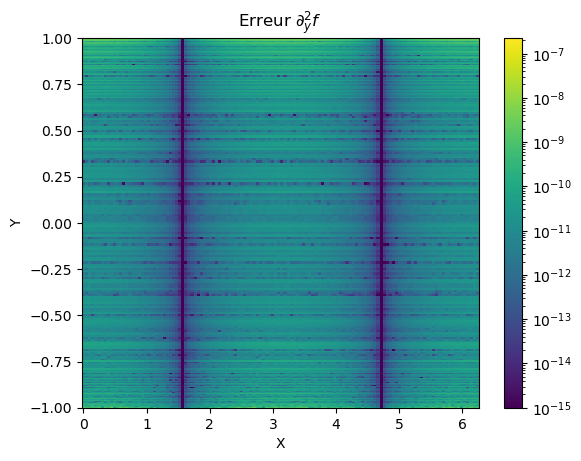

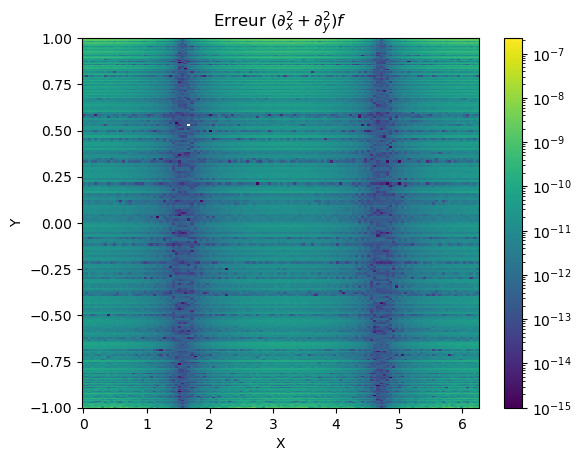

In [4]:
f = lambda xx, yy : (np.cos(xx)**2)*np.cosh(yy)
fp_x = lambda xx, yy : -np.sin(2.0*xx)*np.cosh(yy)
fpp_x = lambda xx, yy : -2.0*np.cos(2.0*xx)*np.cosh(yy)
fp_y = lambda xx, yy : (np.cos(xx)**2)*np.sinh(yy)
fpp_y = lambda xx, yy : (np.cos(xx)**2)*np.cosh(yy)
lapl_f = lambda xx, yy: fpp_x(xx, yy) + fpp_y(xx, yy)


I_ana = 2.0 * np.pi*np.sinh(1.0)

f_ana = f(Grd.X, Grd.Y)

fp_x_ana = fp_x(Grd.X, Grd.Y)
fpp_x_ana = fpp_x(Grd.X, Grd.Y)

fp_y_ana = fp_y(Grd.X, Grd.Y)
fpp_y_ana = fpp_y(Grd.X, Grd.Y)


fp_x_num = Grd.derivative(f_ana, "x")
fpp_x_num = Grd.derivative(f_ana, "x", order = 2)

fp_y_num = Grd.derivative(f_ana, "y")
fpp_y_num = Grd.derivative(f_ana, "y", order = 2)

lapl_f_ana = lapl_f(Grd.X, Grd.Y)
lapl_f_num = Grd.laplacien(f_ana)
##I_num = Grd.integrate_all_domain(f_ana)

err_fp_x = np.abs(fp_x_num - fp_x_ana)
err_fpp_x = np.abs(fpp_x_num - fpp_x_ana)

err_fp_y = np.abs(fp_y_num - fp_y_ana)
err_fpp_y = np.abs(fpp_y_num - fpp_y_ana)


err_lapl = np.abs(lapl_f_ana - lapl_f_num)
#err_I = np.abs(I_ana - I_num)

#print(f"err_I = {err_I:.5e}")


def plot_err(err_array, title='', lognorm = True):
    fig  = plt.figure()
    ax=plt.axes()
    ax.set_title(title)
    cf = ax.pcolormesh(Grd.X, Grd.Y, err_array, norm=colors.LogNorm(vmin=1.0e-15, vmax=err_array.max()) if lognorm else None)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(cf, ax=ax)


plot_err(f_ana, title = 'f(x)', lognorm = False)
plot_err(fp_x_ana, title = r'$\partial_x f(x, y)$ analytique', lognorm = False)
plot_err(fp_x_num, title = r'$\partial_x f(x, y)$ numerique', lognorm = False)

plot_err(fp_y_ana, title = r'$\partial_y f(x, y)$ analytique', lognorm = False)
plot_err(fp_y_num, title = r'$\partial_y f(x, y)$ numerique', lognorm = False)


plot_err(err_fp_x, title = r"Erreur $\partial_x f$")
plot_err(err_fpp_x, title = r"Erreur $\partial_x^2 f$")
plot_err(err_fp_y, title = r"Erreur $\partial_y f$")
plot_err(err_fpp_y, title = r"Erreur $\partial_y^2 f$")
plot_err(err_lapl, title = r"Erreur $(\partial_x^2+\partial_y^2)f$")

In [5]:
I_num = Grd.integrate_all_domain(f_ana)
err_I = np.abs(I_ana - I_num)
print(f"err_I = {err_I:.5e}")

err_I = 8.88178e-16


In [6]:
f_exp = np.exp(np.sin(Grd.X*Grd.Y))
Jac_F = Grd.jacobien(f_exp, f_exp, BC_B = True)
Jac_F

array([[ 1.88124953e-03,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.12638814e-01],
       [ 1.68656991e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -1.59271364e+00],
       [ 9.39814177e-01,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -5.43773612e-01],
       ...,
       [-3.56258825e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  6.55594770e+00],
       [-4.88085405e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  6.94695441e+00],
       [-3.72365493e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  4.65702468e+00]])

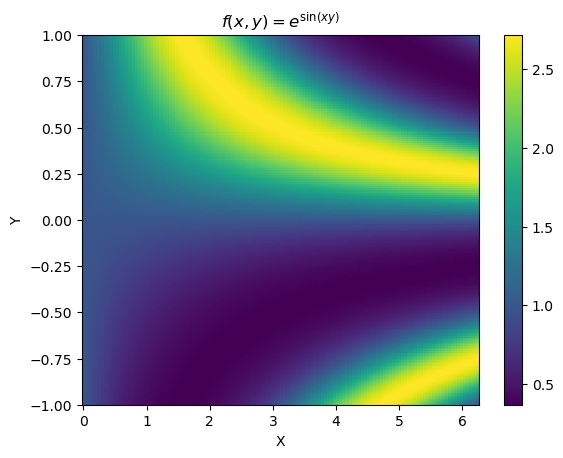

In [7]:
plot_err(f_exp,title = r"$f(x, y) = e^{\sin(xy)}$", lognorm = False)

In [8]:
Jac_F.max()

10.98149220030455

In [9]:
%timeit Grd.integrate_all_domain(f_ana)

36 μs ± 5.45 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [10]:
%timeit Grd.derivative(f_ana, "y")

296 μs ± 26.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
%timeit Grd.derivative(f_ana, "x")

584 μs ± 32.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [12]:
%timeit Grd.jacobien(f_ana, f_ana, BC_B = False)

6 ms ± 234 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [13]:
np.abs(Jac_F).max()

10.98149220030455

## Test de la grille biperiodique

## Test de la classe Variable

In [14]:
import importlib
# next import your module
import variable
# force the module to reload each time the cell runs
importlib.reload(variable)

V = variable.Variable(name = 'toto',
                      type_var = 'diagnostic', 
                      units = '', 
                      field = False,
                      attrs = '')
print(V)


        Variable : 
        Immutables attributes : 
        - name = toto
        - type = diagnostic
        - units = 
        - field = False
        - attrs = 
        mutable attributes
        - value = 0.0


In [15]:
V.value = 0.0

In [16]:
V_2 = variable.Variable(name = 'titi',
                      type_var = 'prognostic', 
                      units = '', 
                      field = True,
                      attrs = '')
V_2.value = 1.0
V == V_2

False

In [17]:
V_3 = variable.Variable(name = 'tata',
                      type_var = 'prognostic', 
                      units = '', 
                      field = False,
                      attrs = '')
V_3 == V

False

In [18]:
V


        Variable : 
        Immutables attributes : 
        - name = toto
        - type = diagnostic
        - units = 
        - field = False
        - attrs = 
        mutable attributes
        - value = 0.0

In [19]:
V_3


        Variable : 
        Immutables attributes : 
        - name = tata
        - type = prognostic
        - units = 
        - field = False
        - attrs = 
        mutable attributes
        - value = 0.0

## Test de la classe `State`

In [20]:
import state
importlib.reload(state)

<module 'state' from 'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\pyTQG_solver\\state.py'>

In [21]:
S = state.State()

V1 = variable.Variable(name = 'V1', type_var = 'prognostic', field = False)

V2 = variable.Variable(name = 'V2', type_var = 'diagnostic', field = True)

V1.value = np.arange(0.0, 10.5)
V2.value = 0.5

S.add_variables(V1, V2)

print(S)
new_S = S.copy()
print(type(new_S))
new_S = 2.0*S
print(new_S)
new_S = new_S+S
print(new_S) 
print(S)

new_S['V1'].value *= 2.0
print(new_S)
print(type(new_S))

new_S+=S
print(new_S)

 
        State : 
        - data_vars = ['V1', 'V2']
        - prognostics_vars = ['V1']
        - diagnostics_vars = ['V2']
        - arrays vars = ['V2']
        - fields vars = ['V1']
        - values = {'V1': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]), 'V2': 0.5}
        
<class 'state.State'>
 
        State : 
        - data_vars = ['V1', 'V2']
        - prognostics_vars = ['V1']
        - diagnostics_vars = ['V2']
        - arrays vars = ['V2']
        - fields vars = ['V1']
        - values = {'V1': array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]), 'V2': 0.5}
        
 
        State : 
        - data_vars = ['V1', 'V2']
        - prognostics_vars = ['V1']
        - diagnostics_vars = ['V2']
        - arrays vars = ['V2']
        - fields vars = ['V1']
        - values = {'V1': array([ 0.,  3.,  6.,  9., 12., 15., 18., 21., 24., 27., 30.]), 'V2': 0.5}
        
 
        State : 
        - data_vars = ['V1', 'V2']
        - prognostics_vars = [

### Test sur modèle SIR

In [22]:
import copy

 
        State : 
        - data_vars = ['S', 'I', 'R', 'N']
        - prognostics_vars = ['S', 'I', 'R']
        - diagnostics_vars = ['N']
        - arrays vars = []
        - fields vars = ['S', 'I', 'R', 'N']
        - values = {'S': array([0.7]), 'I': array([0.3]), 'R': array([0.]), 'N': array([1.])}
        
<class 'state.State'>
schéma d'intégration : LeapFrog


<xarray.Dataset> Size: 11kB
Dimensions:  (t: 281)
Coordinates:
  * t        (t) float64 2kB 0.0 0.11 0.2 0.3 0.4 ... 27.6 27.7 27.8 27.9 28.0
Data variables:
    S        (t) float64 2kB 0.7 0.6884 0.6788 ... 0.003931 0.003905 0.003879
    I        (t) float64 2kB 0.3 0.3088 0.3161 0.3242 ... 0.1323 0.1312 0.1302
    R        (t) float64 2kB 0.0 0.00279 0.005134 ... 0.8638 0.8649 0.866
    N        (t) float64 2kB 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0 1.0
Attributes: (12/24)
    Nx:                     128
    Ny:                     256
    x_bounds:               (0.0, 6.283185307179586)
    y_bounds:               (-1.0, 1.0)
    list_geometry:          ('basin', 'biperiodic', 'zonal_channel')
    geometry:               zonal_channel
    ...                     ...
    freq_diags:             0.1
    apply_dealias:          True
    dealias_order:          after_product
    dealias_Fourier_coeff:  0.6666666666666666
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0

S_SIR is TS.u False


Text(0.5, 0, 't')

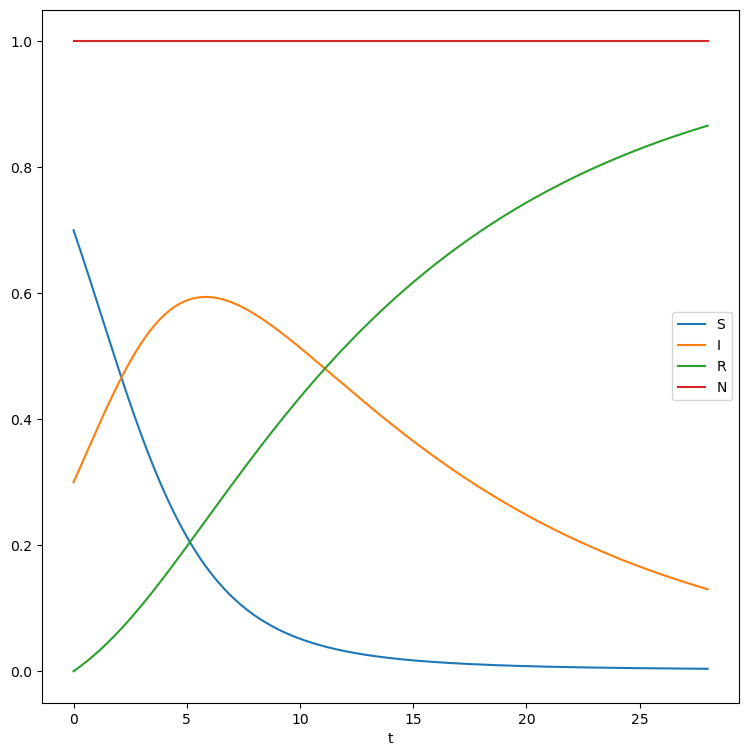

In [23]:
S = variable.Variable(name = "S", field=False, type_var='prognostic', attrs = 'Sains')
I = variable.Variable(name = "I", field=False, type_var='prognostic', attrs = 'Infectes')
R = variable.Variable(name = "R", field=False, type_var='prognostic', attrs = 'Retablis')
N = variable.Variable(name = "N", field=False, type_var='diagnostic', attrs = 'Total')


S_SIR = state.State()
S_SIR.add_variables(S, I, R, N)

S_SIR["S"].value = np.array([0.7])
S_SIR["I"].value = np.array([0.3])
S_SIR["R"].value = np.array([0.0])
S_SIR["N"].value = S_SIR["S"].value + S_SIR["I"].value + S_SIR["R"].value

params.time_scheme = 'LeapFrog'
Tmax = 28.0
dt = 0.01
step_output = 0.1
t_output  = step_output

gamma = 1.0/12.0
beta = 0.5

def RHS_SIR(S_, t):
    #print(f"S_ = {S_}")
    #print(f"type(S_) = {type(S_)}")
    new_S = S_.copy()
    #print(f"new_S = {new_S}")#state
    #print(f"type(new_S) {type(new_S)}")#numpy.ndarray !!!
    new_S['S'].value = -beta * S_['S'].value * S_['I'].value
    new_S['I'].value = beta * S_['S'].value * S_['I'].value - gamma * S_['I'].value
    new_S['R'].value = gamma * S_['I'].value
    return new_S

print(S_SIR)
print(type(S_SIR))
TS = time_scheme.TimeScheme(params, RHS_SIR, S_SIR)

t = 0.0
liste_t = [0.0]
Ds_out = xr.Dataset(data_vars = {'S':(['t'], S_SIR['S'].value),
                                 'I':(['t'], S_SIR['I'].value),
                                 'R':(['t'], S_SIR['R'].value),
                                 'N':(['t'], S_SIR['N'].value)},
                    coords = {'t':('t', [t])}
                   )
Ds_out.attrs = params.to_NETCDF_attrs()

print(f"schéma d'intégration : {params.time_scheme}")
while t < Tmax:
    t+=dt
    TS.Step(dt)
    #Calcul des diagnostics
    S_SIR['N'].value = S_SIR["S"].value + S_SIR["I"].value + S_SIR["R"].value
    #Sauvegarde
    if t >= t_output : 
        t_output += step_output
        Ds_t = xr.Dataset(data_vars = {'S':(['t'], TS.u['S'].value),
                                       'I':(['t'], TS.u['I'].value),
                                       'R':(['t'], TS.u['R'].value), 
                                       'N':(['t'], TS.u['N'].value)},
                    coords = {'t':('t', [t])}
                   )
        Ds_out = xr.concat([Ds_out, Ds_t], 't')

ipd.display(Ds_out)
print(f"S_SIR is TS.u {S_SIR is TS.u}")
fig = plt.figure(figsize = (9, 9))
t = Ds_out.coords['t'].values
plt.plot(t, Ds_out['S'], label = 'S')
plt.plot(t, Ds_out['I'], label = 'I')
plt.plot(t, Ds_out['R'], label = 'R')
plt.plot(t, Ds_out['N'], label = 'N')

plt.legend()
plt.xlabel('t')

## Test de la classe BarotropicQG

In [24]:
import qg_barotropic

import init_fields
importlib.reload(qg_barotropic)

<module 'qg_barotropic' from 'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\pyTQG_solver\\qg_barotropic.py'>

Model : BarotropicQG 
prognostics variables : 
 - PV, field = True 
diagnostics variables : 
 - psi, field = True 
 - vorticity, field = True 
 - kinetic_energy, field = False 
 - potential_energy, field = False 
 - total_energy, field = False 
 - PV_total, field = False 
 - enstrophy, field = False 
parameters : 
 - beta = 0.0
 - inv_Rd2 = 0.0
 - T_0 = -4.0
Elliptic Solver : HelhmholtzChannel
Size of matrices in memory : 63.13 MiB



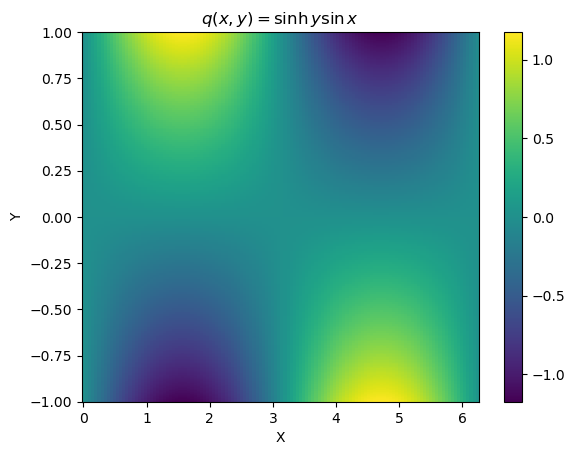

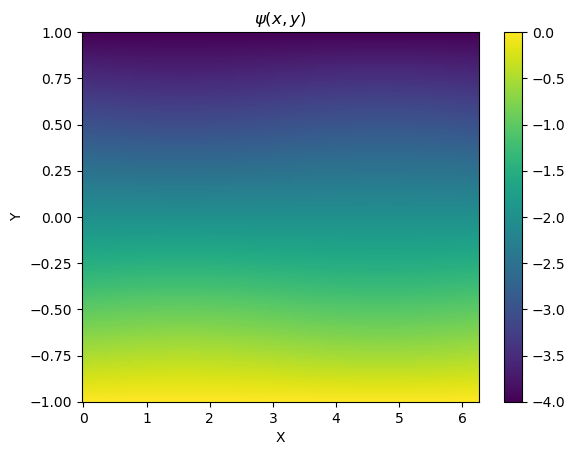

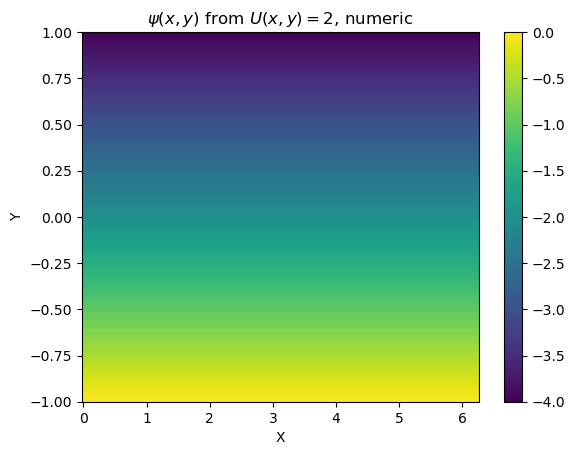

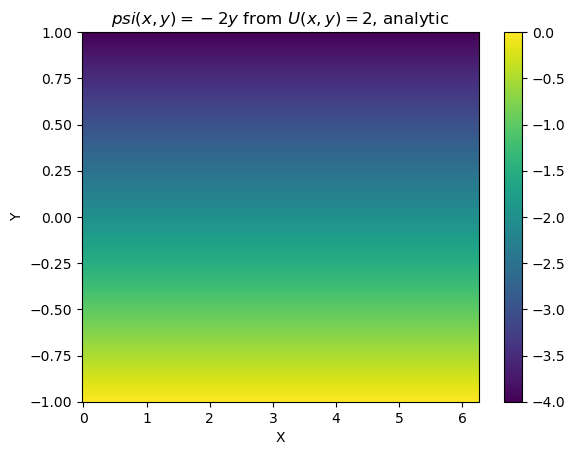

In [25]:
QG_BT = qg_barotropic.BarotropicQG(params, Grd)
QG_BT.T_0 = -4.0
print(QG_BT)
Init_PV = np.sinh(Grd.Y)*np.sin(Grd.X)
psi_0 = QG_BT.psi_from_PV(Init_PV)

plot_err(Init_PV, lognorm = False, title = r"$q(x, y) = \sinh{y}\sin{x}$")
plot_err(psi_0, lognorm = False, title = r"$\psi(x, y)$")

Init_U = init_fields.UniformJet(Grd.Y, 2.0)
psi_U_int = QG_BT.psi_from_U(Init_U)
psi_U_ana = -2.0*Grd.Y-2.0

plot_err(psi_U_int, lognorm = False, title = r"$\psi(x, y)$ from $U(x, y) = 2$, numeric")
plot_err(psi_U_ana, lognorm = False, title = r"$psi(x, y) = -2y$ from $U(x, y) = 2$, analytic")

In [26]:
QG_BT.State.values

{'psi': 0.0,
 'vorticity': 0.0,
 'PV': 0.0,
 'kinetic_energy': 0.0,
 'potential_energy': 0.0,
 'total_energy': 0.0,
 'PV_total': 0.0,
 'enstrophy': 0.0}

In [27]:
QG_BT.to_NETCDF_attrs()

{'Model': 'BarotropicQG', 'beta': 0.0, 'inv_Rd2': 0.0, 'T_0': -4.0}

In [28]:
import os

In [29]:
p = Path(os.getcwd())
p

WindowsPath('C:/Users/evanl/Documents/Cours M2 POC/Stage LOPS/pyTQG/Tests_notebooks')

In [30]:
p/'toto'/"fichier.nc"

WindowsPath('C:/Users/evanl/Documents/Cours M2 POC/Stage LOPS/pyTQG/Tests_notebooks/toto/fichier.nc')

In [31]:
type(p)

pathlib.WindowsPath

In [32]:
str(p)

'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\Tests_notebooks'

In [33]:
val = np.random.random((4, 4))
val

array([[0.08590404, 0.13227929, 0.15989809, 0.67260677],
       [0.42114026, 0.96926496, 0.3634516 , 0.15816159],
       [0.03066985, 0.58267348, 0.55515583, 0.29540225],
       [0.79118756, 0.61906483, 0.85434301, 0.70865788]])

In [34]:

Da = xr.Dataset(data_vars = {'data' : (['x', 'y'], val)},
                coords={'x':('x', [0, 1, 2, 3]), 'y' : ('y', [-2, -1, 0, 1])}
               )
ipd.display(Da)

<xarray.Dataset> Size: 160B
Dimensions:  (x: 4, y: 4)
Coordinates:
  * x        (x) int32 16B 0 1 2 3
  * y        (y) int32 16B -2 -1 0 1
Data variables:
    data     (x, y) float64 128B 0.0859 0.1323 0.1599 ... 0.6191 0.8543 0.7087

In [35]:
import netCDF4 as nc4

In [36]:
Da_t = Da.expand_dims({'t': [0]})
Da_t

<xarray.Dataset> Size: 164B
Dimensions:  (t: 1, x: 4, y: 4)
Coordinates:
  * t        (t) int32 4B 0
  * x        (x) int32 16B 0 1 2 3
  * y        (y) int32 16B -2 -1 0 1
Data variables:
    data     (t, x, y) float64 128B 0.0859 0.1323 0.1599 ... 0.8543 0.7087

In [37]:


with nc4.Dataset(os.getcwd()+r'toto.nc', mode = 'w', format = 'NETCDF4') as NC_file:
    NC_file.createDimension('t', None)
    NC_file.createVariable('t', 'f8', ('t',))

    
    NC_file.createDimension('x', 4)
    x_NC = NC_file.createVariable('x', 'f8', ('x',))
    x_NC[:] = Da_t.coords['x'].values
    
    NC_file.createDimension('y', 4)
    y_NC = NC_file.createVariable('y','f8', ('y',))
    y_NC[:] = Da_t.coords['y'].values.astype(float)

    NC_file.createVariable('data', 'f8', ('t', 'x', 'y'))
    NC_file.sync()

del NC_file

In [38]:
idx_t = 0

In [39]:
val_2 = np.random.random((4, 4)),

#new_Da = new_Da.expand_dims({'t': [1]})
def write_t():
    with nc4.Dataset(os.getcwd()+r'toto.nc', mode = 'r+', format = 'NETCDF4') as nc_file :
        val_2 = np.random.random((4, 4)),
        nc_file.variables['t'][idx_t] = idx_t
        nc_file.variables['data'][idx_t, :, :] = val_2
        nc_file.sync()
write_t()
idx_t+=1

new_Da_2 = xr.open_dataset(os.getcwd()+r'toto.nc')
new_Da_2.close()
new_Da_2


<xarray.Dataset> Size: 200B
Dimensions:  (t: 1, x: 4, y: 4)
Coordinates:
  * t        (t) float64 8B 0.0
  * x        (x) float64 32B 0.0 1.0 2.0 3.0
  * y        (y) float64 32B -2.0 -1.0 0.0 1.0
Data variables:
    data     (t, x, y) float64 128B ...

In [40]:
import zlib

In [41]:
zlib.__version__

'1.0'

In [42]:
import output
import os
importlib.reload(output)

<module 'output' from 'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\pyTQG_solver\\output.py'>

In [43]:
path_courant = Path(os.getcwd())
params.exp_name = 'Output_test'
params.user_attrs = {'mon cul' : 'poulet'}
print(path_courant)
Output = output.Output(params, QG_BT, Grd, path_courant)

params.time_scheme = 'Euler'
print(QG_BT)

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Tests_notebooks
Model : BarotropicQG 
prognostics variables : 
 - PV, field = True 
diagnostics variables : 
 - psi, field = True 
 - vorticity, field = True 
 - kinetic_energy, field = False 
 - potential_energy, field = False 
 - total_energy, field = False 
 - PV_total, field = False 
 - enstrophy, field = False 
parameters : 
 - beta = 0.0
 - inv_Rd2 = 0.0
 - T_0 = -4.0
Elliptic Solver : HelhmholtzChannel
Size of matrices in memory : 63.13 MiB



C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver\output.py:39: RuntimeWarning: file C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Tests_notebooks\Output_test_his.nc already exist. It will be deleted and recreated
  warnings.warn(f"file {self.path_his} already exist. It will be deleted and recreated",
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver\output.py:43: RuntimeWarning: file C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Tests_notebooks\Output_test_diags.nc already exist. It will be deleted and recreated
  warnings.warn(f"file {self.path_diag} already exist. It will be deleted and recreated",


In [44]:
params

Params : 
 - Nx = 128
 - Ny = 256
 - x_bounds = (0.0, 6.283185307179586)
 - y_bounds = (-1.0, 1.0)
 - list_geometry = ('basin', 'biperiodic', 'zonal_channel')
 - geometry = zonal_channel
 - dealias_params = DealiasParams(apply_dealias=True, dealias_order='after_product', dealias_Fourier_coeff=0.6666666666666666, dealias_exp_alpha=100.0, dealias_exp_p=8.0)
 - time_scheme = Euler
 - max_time = 10.0
 - max_it = 1000000
 - max_speed = 50.0
 - cfl = 1.0
 - adaptable_dt = True
 - dt = 0.1
 - output_path = C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Tests_notebooks
 - date = 2026:09:10-16:52:11
 - exp_name = Output_test
 - exp_dir = C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
 - freq_his = 0.1
 - freq_diags = 0.1
 - user_attrs = {'mon cul': 'poulet'}

In [45]:
t = 0.0
dt = 0.01
params.time_scheme = 'Euler'


QG_BT.State['psi'].value = psi_U_int
QG_BT.PV_from_psi(psi_U_int, assign = True)
print(type(QG_BT.State['PV'].value))
QG_BT.check_init_fields()
TS = time_scheme.TimeScheme(params,
                            QG_BT.RHS,
                            QG_BT.State,
                            copy_initial = False)
for i in range(0, 10):
    t += dt
    TS.Step(dt)
    QG_BT.compute_diagnostics()
    print(QG_BT.disp_diags())
    Output.save_his(t)
    Output.save_diags(t)

<class 'numpy.ndarray'>
Model BarotropicQG diagnostics : 
 - kinetic_energy = 25.13274122871848 
 - potential_energy = 0.0 
 - total_energy = 25.13274122871848 
 - PV_total = 1.1752226994213005e-09 
 - enstrophy = 2.8824964442763957e-16 

Model BarotropicQG diagnostics : 
 - kinetic_energy = 25.13274122871848 
 - potential_energy = 0.0 
 - total_energy = 25.13274122871848 
 - PV_total = 1.1752226994213005e-09 
 - enstrophy = 2.8824964442763957e-16 

Model BarotropicQG diagnostics : 
 - kinetic_energy = 25.13274122871848 
 - potential_energy = 0.0 
 - total_energy = 25.13274122871848 
 - PV_total = 1.1752226994213005e-09 
 - enstrophy = 2.8824964442763957e-16 

Model BarotropicQG diagnostics : 
 - kinetic_energy = 25.13274122871848 
 - potential_energy = 0.0 
 - total_energy = 25.13274122871848 
 - PV_total = 1.1752226994213005e-09 
 - enstrophy = 2.8824964442763957e-16 

Model BarotropicQG diagnostics : 
 - kinetic_energy = 25.13274122871848 
 - potential_energy = 0.0 
 - total_energy 

In [46]:
QG_BT

Model : BarotropicQG 
prognostics variables : 
 - PV, field = True 
diagnostics variables : 
 - psi, field = True 
 - vorticity, field = True 
 - kinetic_energy, field = False 
 - potential_energy, field = False 
 - total_energy, field = False 
 - PV_total, field = False 
 - enstrophy, field = False 
parameters : 
 - beta = 0.0
 - inv_Rd2 = 0.0
 - T_0 = -4.0
Elliptic Solver : HelhmholtzChannel
Size of matrices in memory : 63.13 MiB

In [47]:
import fourier

In [48]:
xx = np.linspace(0.0, 2.0*np.pi, endpoint = False)
X, Y = np.meshgrid(xx, xx, indexing = 'ij')
f_xx = np.sin(X)*np.cos(Y)

fourier.Fourier_deriv(f_xx, axis = "y")

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.25097433e-16, -1.57084194e-02, -3.11691077e-02, ...,
         4.61382405e-02,  3.11691077e-02,  1.57084194e-02],
       [ 2.52184271e-16, -3.11691077e-02, -6.18466600e-02, ...,
         9.15488535e-02,  6.18466600e-02,  3.11691077e-02],
       ...,
       [-2.62996895e-16,  4.61382405e-02,  9.15488535e-02, ...,
        -1.35515686e-01, -9.15488535e-02, -4.61382405e-02],
       [ 1.02091783e-15,  3.11691077e-02,  6.18466600e-02, ...,
        -9.15488535e-02, -6.18466600e-02, -3.11691077e-02],
       [ 2.13866691e-16,  1.57084194e-02,  3.11691077e-02, ...,
        -4.61382405e-02, -3.11691077e-02, -1.57084194e-02]])

In [49]:
print(QG_BT.State.scalar_vars)
print(QG_BT.State.scalar_values)

['kinetic_energy', 'potential_energy', 'total_energy', 'PV_total', 'enstrophy']
{'kinetic_energy': 25.13274122871848, 'potential_energy': 0.0, 'total_energy': 25.13274122871848, 'PV_total': 1.1752226994213005e-09, 'enstrophy': 2.8824964442763957e-16}


In [50]:

print(QG_BT.State.fields_vars)
print(QG_BT.State.fields_values)

['psi', 'vorticity', 'PV']
{'psi': array([[-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00],
       [-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00],
       [-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00],
       ...,
       [-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00],
       [-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00],
       [-4.00000000e+00, -3.99984822e+00, -3.99939290e+00, ...,
        -6.07096044e-04, -1.51779770e-04,  0.00000000e+00]]), 'vorticity': array([[ 1.89572215e-07,  5.25542326e-07,  3.94517514e-07, ...,
        -5.86993647e-11,  1.37301062e-10,  1.40908478e-09],
       [ 1.89572215e-07,  5.25542326e-07,  3.94517514e-07, ...,
      

<xarray.Dataset> Size: 8MB
Dimensions:    (t: 10, x: 128, y: 256)
Coordinates:
  * t          (t) float64 80B 0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1
  * x          (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y          (y) float64 2kB 1.0 0.9999 0.9997 0.9993 ... -0.9997 -0.9999 -1.0
Data variables:
    psi        (t, x, y) float64 3MB ...
    vorticity  (t, x, y) float64 3MB ...
    PV         (t, x, y) float64 3MB ...
Attributes: (12/30)
    title:                  Output_test_his.nc
    Nx:                     128
    Ny:                     256
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    -4.0

<xarray.Dataset> Size: 8MB
Dimensions:    (t: 10, x: 128, y: 256)
Coordinates:
  * t          (t) float64 80B 0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1
  * x          (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y          (y) float64 2kB 1.0 0.9999 0.9997 0.9993 ... -0.9997 -0.9999 -1.0
Data variables:
    psi        (t, x, y) float64 3MB ...
    vorticity  (t, x, y) float64 3MB ...
    PV         (t, x, y) float64 3MB ...
Attributes: (12/30)
    title:                  Output_test_his.nc
    Nx:                     128
    Ny:                     256
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    -4.0

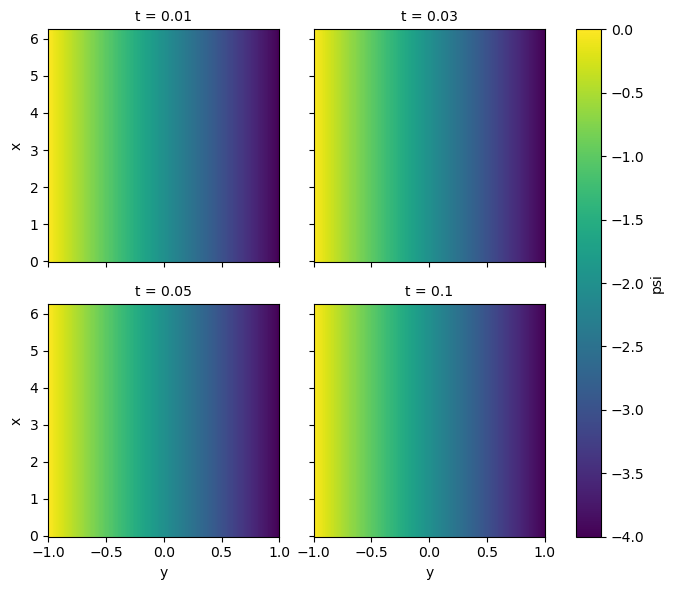

In [51]:
ds_his = xr.open_dataset('Output_test_his.nc')
ipd.display(ds_his)
ds_his.close()
ipd.display(ds_his)
ds_his['psi'].isel(t=[0, 2, 4, 9]).plot.pcolormesh(col = 't', col_wrap = 2)

In [52]:
1/0

ZeroDivisionError: division by zero

In [53]:
print("Vérification que TimeScheme.u, QG_BT.State et Output.Model.State sont bien les memes objets")
print(f"id(TimeScheme.u) = {id(TS.u)}")
print(f"id(QG_BT.State) = {id(QG_BT.State)}")
print(f"QG_BT.State is TS.u {TS.u is QG_BT.State}")
#print(f"id(Output.Model.State) {id(Output.Model.State)}")
#print(f"Output.Model.State is QG_BT.State {Output.Model.State is QG_BT.State}")

Vérification que TimeScheme.u, QG_BT.State et Output.Model.State sont bien les memes objets
id(TimeScheme.u) = 1739781300608
id(QG_BT.State) = 1739781300608
QG_BT.State is TS.u True


In [ ]:
ds_his['psi'].isel(t=0).values

In [ ]:
ds = xr.load_dataset('Output_test_diags.nc')
ipd.display(ds)
ds.close()

In [ ]:
QG_BT.max_speed()

In [ ]:
vort_rel = QG_BT.vort_from_U(Init_U)
QG_BT.PV_from_vort(vort_rel)

In [ ]:
d = {'a': 1, 'b':0}
d1 = {}
d2 = {**d, **d1}
d2

In [ ]:
len(d2)

In [ ]:
for key, val in d2.items():
    print(f"{key} = {val}")

In [ ]:
repertoire_courant = Path.cwd()
print(repertoire_courant)
print(repertoire_courant.parent.parent)

In [ ]:
import shutil
import warnings
import pathlib

name_file = 'log_test.txt'
file_to_copy = repertoire_courant / name_file
repertoire_copy = repertoire_courant / 'toto'
file_copied = repertoire_copy / name_file


print(f"fichier à copier : {file_to_copy}")
print(f"repertoire de copie {repertoire_copy}")

try : 
    if file_copied.is_file() :
        print(f"Attention, le fichier {name_file} existe déjà. Voulez vous l'écraser ?")
        #reponse = input("y/n")
        reponse = 'y'
        if reponse == 'y':
            print("Ecrasement")
            print("fait")
        else : 
            print("Ok")
    shutil.copy(file_to_copy, repertoire_copy / name_file)
except Exception as e :
    print(f"problème : {e}, {type(e)}")
print("fin")

In [ ]:
repertoire_bidon = repertoire_courant / 'toto'
repertoire_bidon.is_dir()

In [ ]:
type(0.0) is not np.ndarray

In [ ]:
print(20*'#'+'pyTQG'+20*'#')
print(45*'#')

In [ ]:
v1 = variable.Variable(name='v1', type_var = 'prognostic', field = True)
State_ = state.State()
State_.add_variables(v1)
print(State_)
State_['v1'].value = np.arange(10)
def RHS(state, t):
    new_State = state.copy()
    new_State['v1'].value = state['v1'].value
    return new_State

dt = 0.1
t= 0.0

ts = time_scheme.TimeScheme(params, RHS, State_)

State_ref = State_.copy()
print(20*'#')
for i in range(0, 10):
    t +=dt
    ts.Step(dt)
    State_ref = State_ref + dt*RHS(State_ref, t)
    print(f"t = {t} State_['v1'].value = {State_['v1'].value}")
    print(f"t = {t} State_ref['v1'].value = {State_ref['v1'].value}")
    print(20*'#')

In [ ]:
x = np.arange(10)
print(f"id(x) = {id(x)}")
x = x + 1
print("x = x+1")

print(f"id(x) = {id(x)}")

x += 1
print(f"id(x) = {id(x)}")